# Fake news Detection

### Importing Modules

In [3]:
import pandas as pd #for importing dataset
import numpy as nm #for doing mathematical operations 
from sklearn.model_selection import train_test_split #to break dataset for training and testing
from sklearn.metrics import classification_report # to generate classification report
import re #for data cleaning purpose
import string #to deal with text data
import matplotlib.pyplot as plt #for visualizing dataset

### Reading two  data files 
### Download this dataset from
https://www.kaggle.com/code/therealsampat/fake-news-detection/data

In [5]:
data_true=pd.read_csv("True.csv")
data_fake=pd.read_csv("Fake.csv")

#### Printing top 5 values from both Dataset 

In [7]:
data_true.head(5)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [8]:
data_fake.head(5)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


#### Checking size of Datasets 

In [10]:
data_true.shape, data_fake.shape

((21417, 4), (23481, 4))

### Adding column name "class" in both datasets

In [12]:
data_true["class"]=1
data_fake["class"]=0

###  Taking last 10 values for manual testing from both Datasets 

In [14]:
data_true_manual_testing = data_true.tail(10)
indices_true = data_true.index[-10:]
data_true.drop(indices_true, axis=0, inplace=True)

data_fake_manual_testing = data_fake.tail(10) 

indices_fake = data_fake.index[-10:]


data_fake.drop(indices_fake, axis=0, inplace=True)
data_fake_manual_testing

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


### merging these two datasets in single dataframe

In [16]:
data_manual_testing = pd.concat([data_fake_manual_testing, data_true_manual_testing], axis=0)
data_manual_testing.to_csv("manual_testing.csv ")

### Merging main two datasets

In [18]:
data_merge = pd.concat([data_fake,data_true],axis=0)
data_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


### Performing some basic data visualizations

subject
Government News     1570
Middle-east          768
News                9050
US_News              783
left-news           4459
politics            6841
politicsNews       11272
worldnews          10135
Name: text, dtype: int64


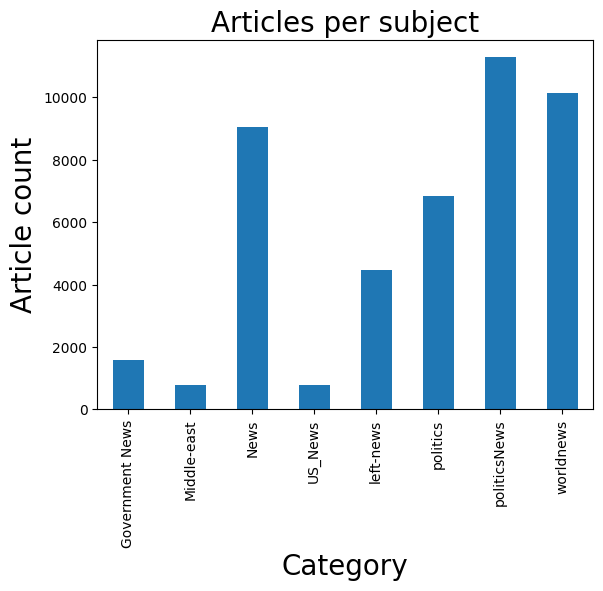

In [20]:
print(data_merge.groupby(['subject'])['text'].count())
data_merge.groupby(['subject'])['text'].count().plot(kind="bar")
plt.title("Articles per subject",size=20)
plt.xlabel("Category",size=20)
plt.ylabel("Article count",size=20)
plt.show()

class
0    23471
1    21407
Name: text, dtype: int64
0 = Fake news
1 = True news


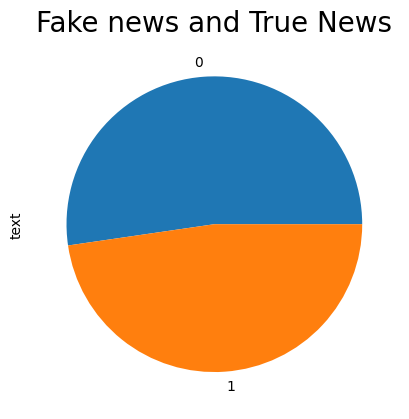

In [21]:
print(data_merge.groupby(['class'])['text'].count())
print("0 = Fake news\n1 = True news")
data_merge.groupby(['class'])['text'].count().plot(kind="pie")
plt.title("Fake news and True News",size=20)
plt.show()

### Removing 3 columns from dataset 

In [23]:
data = data_merge.drop(["title","subject","date"], axis=1)
data.head(10) 

,text,class
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0
5,The number of cases of cops brutalizing and ki...,0
6,Donald Trump spent a good portion of his day a...,0
7,In the wake of yet another court decision that...,0
8,Many people have raised the alarm regarding th...,0
9,Just when you might have thought we d get a br...,0


### Shuffling the dataset for better prediction

In [25]:
data=data.sample(frac=1)
data.head(10)

,text,class
23124,21st Century Wire says As 21WIRE reported on S...,0
17415,"She was an unethical, dishonest lawyer. She c...",0
7052,"The new, ridiculous anti-LGBT law that Mississ...",0
13596,SYDNEY (Reuters) - Australia s upper house Sen...,1
17599,While honoring Native American Code Talkers to...,0
2857,Torture is illegal in this country and the Uni...,0
1749,Rep. Maxine Waters (D-CA) is the physical embo...,0
3321,It s no secret that Donald Trump isn t a fan o...,0
13147,SANTIAGO (Reuters) - The leader of an influent...,1
6417,WASHINGTON (Reuters) - U.S. President-elect Do...,1


### Checking for null values in dataset

In [27]:
data.isnull().sum()

text     0
class    0
dtype: int64

### Creating data filtering function to remove unwanted data from text

In [29]:
import re
import string

def filtering(data):
    text = data.lower()
    
    text = re.sub(r'\[.*?\]', '', text)
    
    text = re.sub(r"\W", " ", text)
    
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    text = re.sub(r'<.*?>', '', text)
   
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    
    text = re.sub(r'\w*\d\w*', '', text)
    
    return text



### Filtering data of our text column using above function

In [31]:
data["text"]= data["text"].apply(filtering)
data.head(10)

,text,class
23124,century wire says as reported on saturday t...,0
17415,she was an unethical dishonest lawyer she c...,0
7052,the new ridiculous anti lgbt law that mississ...,0
13596,sydney reuters australia s upper house sen...,1
17599,while honoring native american code talkers to...,0
2857,torture is illegal in this country and the uni...,0
1749,rep maxine waters d ca is the physical embo...,0
3321,it s no secret that donald trump isn t a fan o...,0
13147,santiago reuters the leader of an influent...,1
6417,washington reuters u s president elect do...,1


### Creating Dependant and independant variables 

In [33]:
print(data.columns)

x = data["text"]
y = data["class"]  


Index(['text', 'class'], dtype='object')


### Spliting dataset for training and testing purpose 

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

### Vectorizing the text
#### The sklearn. feature_extraction module is used to extract features in a format supported by machine learning algorithms from datasets consisting of formats such as text and image

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
vector = TfidfVectorizer(max_features=5000) 
xv_train=vector.fit_transform(x_train)
xv_test=vector.transform(x_test)

## Classifaction using various classifers

### Logictic Regression
#### Calculating probability of event occurence 

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
LR=LogisticRegression()
LR.fit(xv_train,y_train)

LogisticRegression()

In [43]:
accuracy = LR.score(xv_test, y_test)
rounded_accuracy = round(accuracy, 2)
print(f"Logistic Regression Accuracy: {rounded_accuracy}")


Logistic Regression Accuracy: 0.98


In [44]:
pred_LR= LR.predict(xv_test) 

In [45]:
print(classification_report(y_test,pred_LR)) 

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5879
           1       0.98      0.99      0.98      5341

    accuracy                           0.98     11220
   macro avg       0.98      0.99      0.98     11220
weighted avg       0.98      0.98      0.98     11220



### Creating confusion matrix
#### determine the performance of the classification models for a given set of test data.

[[5782   97]
 [  72 5269]]


<Axes: >

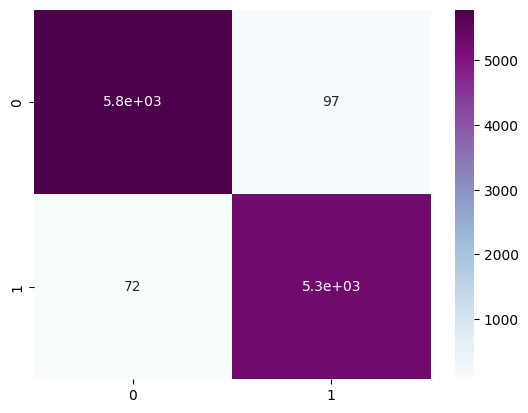

In [47]:
from sklearn.metrics import confusion_matrix  
cm= confusion_matrix(y_test,pred_LR)  
print(cm)
import seaborn as sns
sns.heatmap(cm,cmap="BuPu",annot=True)


## Manual Testing

In [80]:
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier


data = pd.DataFrame({
    'text': ['This is real news', 'This is fake news', 'Another real news', 'Another fake news'],
    'label': [1, 0, 1, 0]  # 0 = Real, 1 = Fake
})


def filtering(text):
    return text.lower()


data['text'] = data['text'].apply(filtering)
X = data['text']
y = data['label']


vector = TfidfVectorizer(stop_words='english', max_df=0.7)
X = vector.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


pac = PassiveAggressiveClassifier(max_iter=50)
pac.fit(X_train, y_train)

DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)

GBC = GradientBoostingClassifier()
GBC.fit(X_train, y_train)

RFC = RandomForestClassifier()
RFC.fit(X_train, y_train)


def output_label(label):
    return "Fake" if label == 0 else "Real"

def get_model_accuracies(news):
    
    testing_news = {"text": [news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(filtering)
    new_x_test = new_def_test["text"]
    new_xv_test = vector.transform(new_x_test)

    
    pred_pac = pac.predict(new_xv_test) 
    pred_DT = DT.predict(new_xv_test)    
    pred_GBC = GBC.predict(new_xv_test)  
    pred_RFC = RFC.predict(new_xv_test) 
    
    
    predictions = {
        "PAC": output_label(pred_pac[0]),
        "Decision Tree": output_label(pred_DT[0]),
        "Gradient Boosting": output_label(pred_GBC[0]),
        "Random Forest": output_label(pred_RFC[0])
    }
    
    print("Model predictions: ", predictions)
    
   
    final_prediction = majority_voting(predictions)
    
    return final_prediction


def majority_voting(predictions):
    votes = list(predictions.values())
    true_votes = votes.count("Real")
    fake_votes = votes.count("Fake")
    
    
    if true_votes > fake_votes:
        return "True (Real News)"
    else:
        return "False (Fake News)"


def check_news_validity(news):
    result = get_model_accuracies(news)
    print(f"The news is: {result}")


news = str(input("Enter news text for validity testing: "))
check_news_validity(news)


Enter news text for validity testing:   Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People â€˜In The Eyeâ€™


Model predictions:  {'PAC': 'Fake', 'Decision Tree': 'Fake', 'Gradient Boosting': 'Real', 'Random Forest': 'Real'}
The news is: False (Fake News)
